In [ ]:
# =========================
# STEP 0 — IMPORTS & SETTINGS
# =========================

# pandas: table manipulation
import pandas as pd
# numpy: numerical operations
import numpy as np
# plotting: matplotlib + seaborn for nicer visuals
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn utilities for dataset and evaluation split
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# statsmodels for OLS regression and diagnostics
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Keep plotting style consistent
sns.set(context="notebook", style="ticks")


=== HEAD ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-nu

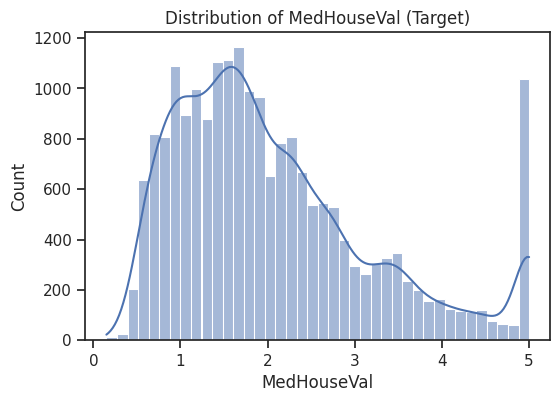

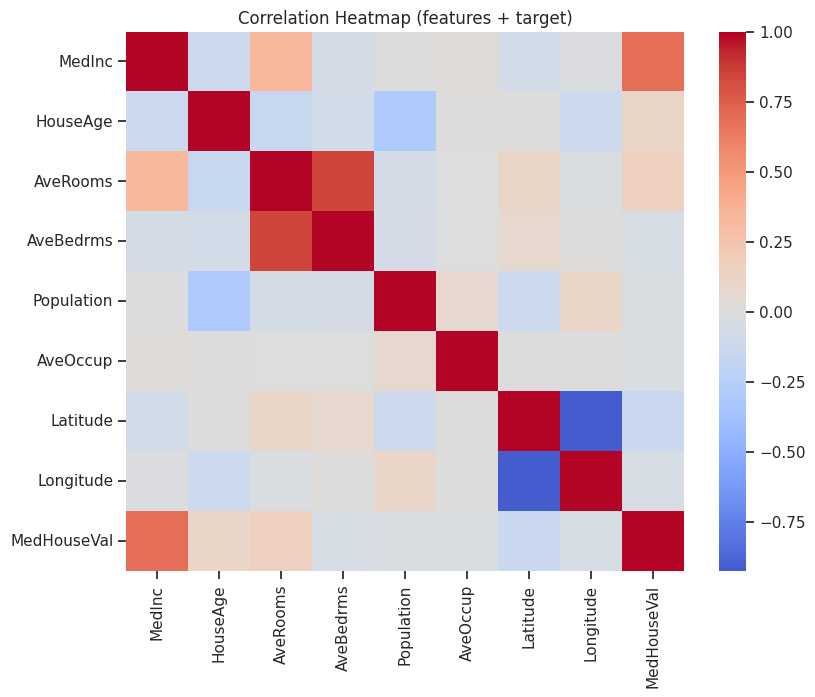

In [ ]:
# =========================
# STEP 1 — LOAD DATA & QUICK EDA
# =========================

# Load the built-in California housing dataset as a pandas DataFrame.
# WHY: convenient, well-known regression dataset with numeric features.
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # contains features + target 'MedHouseVal'

# Quick look at data to verify load
print("=== HEAD ===")
print(df.head())

# Info: types + non-null counts. WHY: detect missing data or odd types.
print("\n=== INFO ===")
print(df.info())

# Summary statistics to understand scales and potential outliers.
print("\n=== DESCRIBE ===")
print(df.describe())

# Check for missing values — OLS cannot handle NaNs directly.
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Quick look at target distribution — if very skewed, consider transform later.
plt.figure(figsize=(6,4))
sns.histplot(df['MedHouseVal'], kde=True, bins=40)
plt.title("Distribution of MedHouseVal (Target)")
plt.show()

# Correlation heatmap — to see strong pairwise linear relationships.
plt.figure(figsize=(9,7))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (features + target)")
plt.show()


In [ ]:
# =========================
# STEP 2 — PREPROCESSING (BASE)
# =========================

# If any NaNs exist (unlikely for this built-in dataset), drop them for simplicity.
# WHY: simple and safe for demonstration; real world -> consider imputation.
df = df.dropna()

# Define feature matrix X and target y
X = df.drop("MedHouseVal", axis=1).copy()
y = df["MedHouseVal"].copy()

# Train-test split to evaluate generalization
# WHY: we must evaluate on unseen data to avoid optimistic estimates.
# Setting random_state to a specific number (like 42) makes the split reproducible — you’ll always get the same split if you use the same seed.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:

# =========================
# STEP 3 — VIF: MULTICOLLINEARITY (BEFORE TUNING)
# =========================

# WHY VIF first? -> tells us if predictors are highly collinear. If so, coefficients may be unstable.
# Compute VIF for the original features (exclude constant when computing).
def compute_vif(df_features):
    """
    Return DataFrame with VIF for each feature in df_features (no constant expected).
    - Input: df_features : pandas.DataFrame of numeric predictor columns (each column = one feature).
    - Output: pandas.DataFrame with two columns: 'feature' (name) and 'VIF' (numeric VIF value).
    """
    # Create an empty DataFrame to hold the results (feature names + their VIF values).
    # WHY: we want a clean tabular result that is easy to inspect/sort/print.
    vif_df = pd.DataFrame()

    # Copy the feature names (column labels) into the result DataFrame under the "feature" column.
    # WHY: keep track of which VIF corresponds to which original feature (maintains order).
    vif_df["feature"] = df_features.columns

    # Compute VIF for each feature and store results in the "VIF" column.
    # The list comprehension iterates over column indexes i = 0 .. (n_features-1).
    # variance_inflation_factor(exog, i) expects:
    #   - eg: 2D array-like of shape (n_samples, n_features) — the design matrix of predictors
    #   - i: integer index of the column within exog for which to compute VIF
    #
    # We pass df_features.values (a NumPy 2D array) because statsmodels' helper accepts ndarray,
    # and it's slightly faster than passing a DataFrame directly.
    #
    # WHY: VIF_i = 1 / (1 - R_i^2), where R_i^2 is the R-squared from regressing feature i on all other features.
    # A high VIF means that the i-th feature is highly explained by the other features (multicollinearity).
    vif_df["VIF"] = [
        variance_inflation_factor(df_features.values, i)
        for i in range(df_features.shape[1])
    ]

    # Return the DataFrame with feature names and their corresponding VIF values.
    # WHY: caller can sort, filter, or inspect these values to decide whether to drop/transform features.
    return vif_df


vif_before = compute_vif(X)  # X is the features before any transform
print("\n=== VIF (Before Tuning) ===")
print(vif_before.sort_values("VIF", ascending=False))



=== VIF (Before Tuning) ===
      feature         VIF
7   Longitude  633.711654
6    Latitude  559.874071
2    AveRooms   45.993601
3   AveBedrms   43.590314
0      MedInc   11.511140
1    HouseAge    7.195917
4  Population    2.935745
5    AveOccup    1.095243



=== BASE OLS SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Tue, 02 Sep 2025   Prob (F-statistic):               0.00
Time:                        07:35:35   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233     

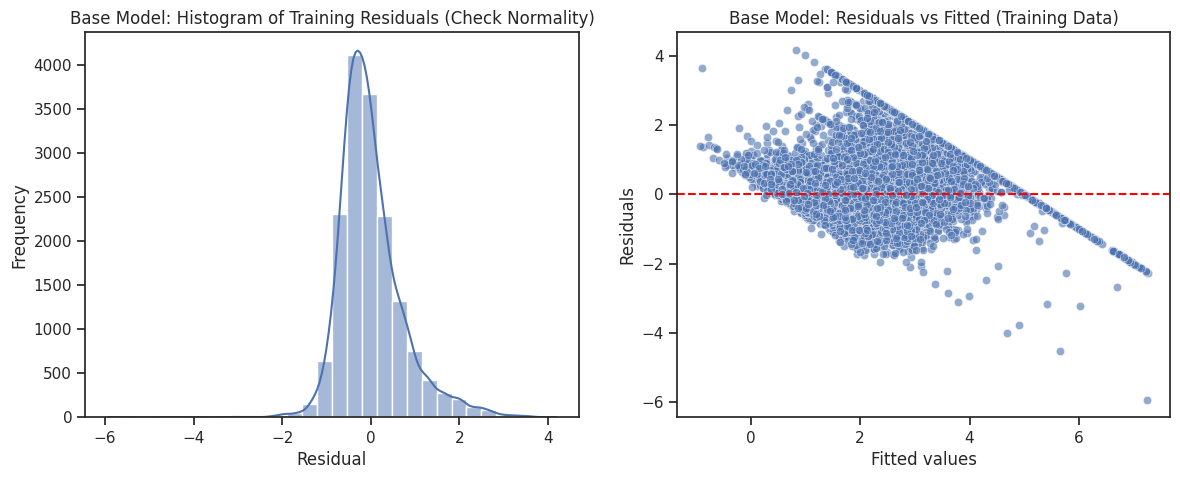

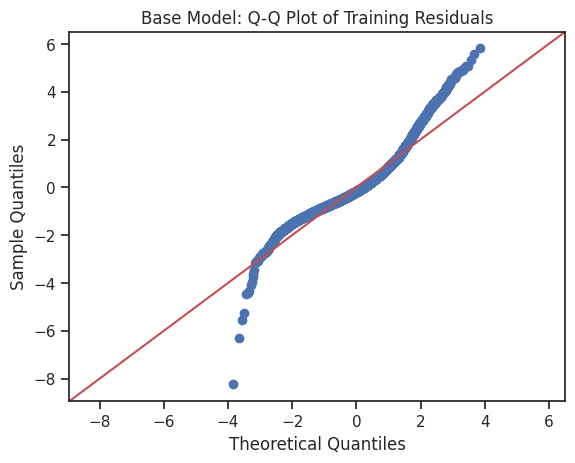

In [ ]:

# Interpretation hint: VIF > 5 (or >10) suggests problematic multicollinearity.
# If you have high VIFs, consider removing or combining features, or using PCA.


# =========================
# STEP 4 — BASELINE OLS MODEL (BEFORE TUNING)
# =========================

# statsmodels OLS requires adding a constant column explicitly for the intercept.
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit OLS on the training set
# WHY: find coefficient estimates that minimize SSR (sum squared residuals)
ols_base = sm.OLS(y_train, X_train_sm).fit()

print("\n=== BASE OLS SUMMARY ===")
print(ols_base.summary())  # p-values, coefficients, R-squared, adj. R-squared, etc.

# Predictions on test data (unseen during training)
y_pred_base = ols_base.predict(X_test_sm)

# Evaluate baseline performance using RMSE and R²
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print("\nBASELINE PERFORMANCE:")
print(f"RMSE (base): {rmse_base:.4f}")
print(f"R²   (base): {r2_base:.4f}")

# Durbin-Watson on training residuals (from the fitted model)
# WHY: tests autocorrelation in residuals (Residuals are the errors of the model on the training data). DW ~ 2 means no autocorrelation.
dw_base = durbin_watson(ols_base.resid)
print(f"Durbin-Watson (base, training residuals): {dw_base:.3f}")


# Residual diagnostics for the base model (training residuals)
resid_base_train = ols_base.resid  # residuals on training data
fitted_base_train = ols_base.fittedvalues

# HISTOGRAM (normality)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(resid_base_train, kde=True, bins=30)
plt.title("Base Model: Histogram of Training Residuals (Check Normality)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

# RESIDUALS vs FITTED (homoscedasticity)
plt.subplot(1,2,2)
sns.scatterplot(x=fitted_base_train, y=resid_base_train, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Base Model: Residuals vs Fitted (Training Data)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

# Q-Q PLOT (normality)
sm.qqplot(resid_base_train, line='45', fit=True)
plt.title("Base Model: Q-Q Plot of Training Residuals")
plt.show()


In [ ]:

# =========================
# STEP 5 — SIMPLE TUNING / FEATURE ENGINEERING
# =========================

# Based on domain knowledge (and often from inspecting relationships), we try:
# - log-transform Median Income (MedInc) because income tends to be skewed and may relate multiplicatively to house price.
# This is a common and effective simple transform for linear models.

# Work on a fresh copy of features to avoid accidental leakage
X_tuned = df.drop("MedHouseVal", axis=1).copy()

# Create log(MedInc). Add a tiny epsilon to avoid log(0) if present.
# A tiny number (0.00000001) is added to avoid log(0), because log of 0 is undefined.
X_tuned["MedInc_log"] = np.log(X_tuned["MedInc"] + 1e-8)

# Drop original 'MedInc' to avoid redundant information and reduce multicollinearity.
X_tuned = X_tuned.drop(columns=["MedInc"])

# Optionally, you could also try transformations on other skewed columns or create interaction terms.
# For this tutorial we keep tuning minimal to clearly show effect.

# Re-split tuned features (use same random_state for consistent train/test split)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tuned, y, test_size=0.20, random_state=42
)


In [ ]:

# =========================
# STEP 6 — VIF AFTER TUNING (TO CHECK IMPROVEMENT)
# =========================

# Recompute VIF on tuned features to see if collinearity improved after dropping original MedInc
vif_after = compute_vif(X_tuned)
print("\n=== VIF (After Tuning) ===")
print(vif_after.sort_values("VIF", ascending=False))

# If some features still show very high VIF, consider:
# - dropping one of a highly correlated pair
# - combining features (e.g., ratios)
# - dimensionality reduction (PCA)



=== VIF (After Tuning) ===
      feature         VIF
6   Longitude  659.999800
5    Latitude  564.922150
1    AveRooms   44.676903
2   AveBedrms   42.723787
7  MedInc_log   17.519660
0    HouseAge    7.208497
3  Population    2.937473
4    AveOccup    1.094634



=== TUNED OLS SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     2617.
Date:                Tue, 02 Sep 2025   Prob (F-statistic):               0.00
Time:                        07:35:36   Log-Likelihood:                -19063.
No. Observations:               16512   AIC:                         3.814e+04
Df Residuals:                   16503   BIC:                         3.821e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.1589    

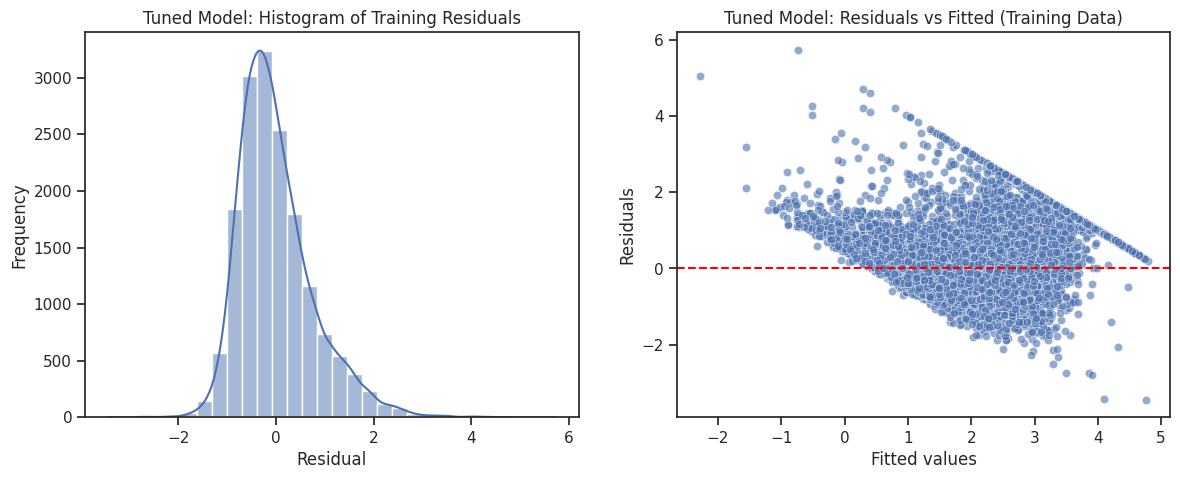

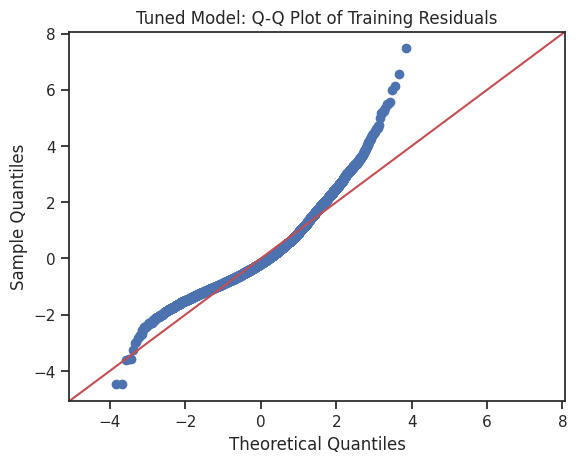

In [ ]:
# =========================
# STEP 7 — FIT TUNED OLS MODEL
# =========================

# Add constant for intercept (statsmodels needs it)
X_train_t_sm = sm.add_constant(X_train_t)
X_test_t_sm  = sm.add_constant(X_test_t)

# Fit OLS on the tuned training set
ols_tuned = sm.OLS(y_train_t, X_train_t_sm).fit()

print("\n=== TUNED OLS SUMMARY ===")
print(ols_tuned.summary())

# Predict with tuned model on tuned test set
y_pred_tuned = ols_tuned.predict(X_test_t_sm)

# Evaluate tuned metrics
mse_tuned = mean_squared_error(y_test_t, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test_t, y_pred_tuned)

print("\nTUNED PERFORMANCE:")
print(f"RMSE (tuned): {rmse_tuned:.4f}")
print(f"R²   (tuned): {r2_tuned:.4f}")

# Durbin-Watson on tuned training residuals
dw_tuned = durbin_watson(ols_tuned.resid)
print(f"Durbin-Watson (tuned, training residuals): {dw_tuned:.3f}")


# Residual diagnostics for the tuned model (training residuals)
resid_tuned_train = ols_tuned.resid
fitted_tuned_train = ols_tuned.fittedvalues

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(resid_tuned_train, kde=True, bins=30)
plt.title("Tuned Model: Histogram of Training Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.scatterplot(x=fitted_tuned_train, y=resid_tuned_train, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Tuned Model: Residuals vs Fitted (Training Data)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

sm.qqplot(resid_tuned_train, line='45', fit=True)
plt.title("Tuned Model: Q-Q Plot of Training Residuals")
plt.show()



=== PERFORMANCE COMPARISON ===
           Model      RMSE        R2
0  Before Tuning  0.745581  0.575788
1   After Tuning  0.784282  0.530605


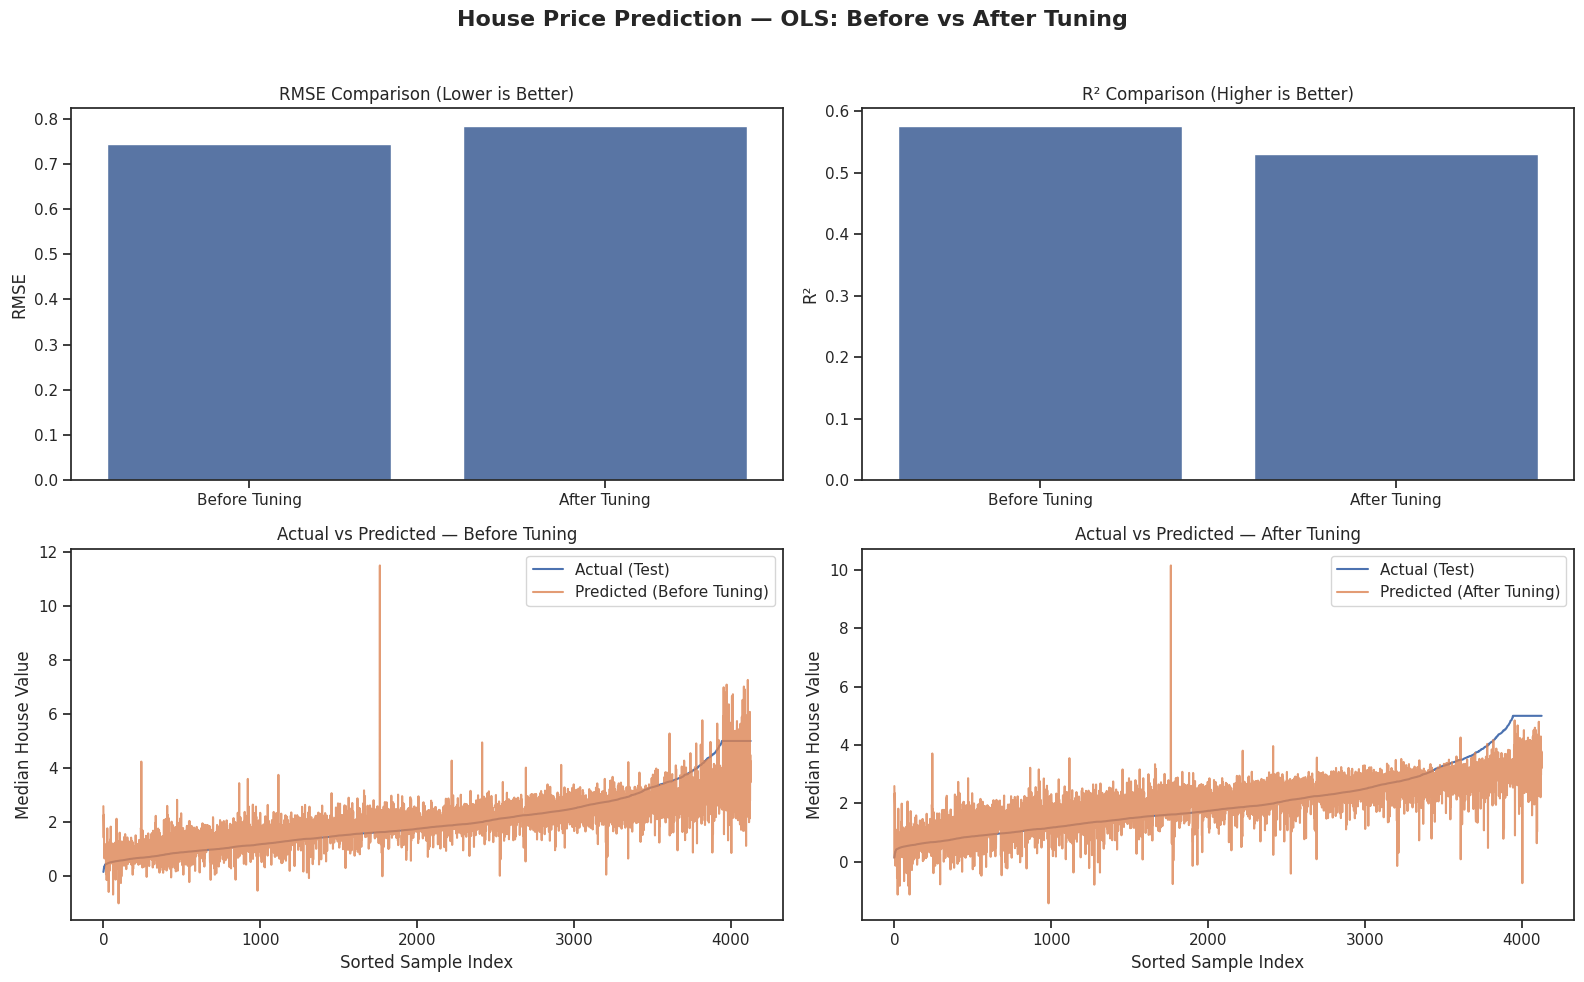

In [ ]:
# =========================
# STEP 8 — PERFORMANCE COMPARISON (BASE vs TUNED) + DASHBOARD
# =========================

# Build a small DataFrame to compare key metrics
performance = pd.DataFrame({
    "Model": ["Before Tuning", "After Tuning"],
    "RMSE": [rmse_base, rmse_tuned],
    "R2":   [r2_base, r2_tuned]
})

print("\n=== PERFORMANCE COMPARISON ===")
print(performance)

# Prepare sorted actuals/predictions for line plots (makes curves easier to inspect)
# Note: base vs tuned splits are identical in this script because we used the same random_state and only transformed features.
y_test_sorted = np.array(y_test)
order = np.argsort(y_test_sorted)

y_test_sorted = y_test_sorted[order]
y_pred_base_sorted = np.array(y_pred_base)[order]

# For tuned test, y_test_t equals y_test because the split used the same random_state and target hasn't changed.
# But indexes might have different order; ensure we sort tuned test as well by target values.
y_test_t_sorted = np.array(y_test_t)
order_t = np.argsort(y_test_t_sorted)
y_test_t_sorted = y_test_t_sorted[order_t]
y_pred_tuned_sorted = np.array(y_pred_tuned)[order_t]


# Combined Dashboard (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# 1) RMSE bar
sns.barplot(x="Model", y="RMSE", data=performance, ax=axes[0,0])
axes[0,0].set_title("RMSE Comparison (Lower is Better)")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("RMSE")

# 2) R² bar
sns.barplot(x="Model", y="R2", data=performance, ax=axes[0,1])
axes[0,1].set_title("R² Comparison (Higher is Better)")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("R²")

# 3) Actual vs Predicted (Before)
axes[1,0].plot(y_test_sorted, label="Actual (Test)")
axes[1,0].plot(y_pred_base_sorted, label="Predicted (Before Tuning)", alpha=0.8)
axes[1,0].set_title("Actual vs Predicted — Before Tuning")
axes[1,0].set_xlabel("Sorted Sample Index")
axes[1,0].set_ylabel("Median House Value")
axes[1,0].legend()

# 4) Actual vs Predicted (After)
axes[1,1].plot(y_test_t_sorted, label="Actual (Test)")
axes[1,1].plot(y_pred_tuned_sorted, label="Predicted (After Tuning)", alpha=0.8)
axes[1,1].set_title("Actual vs Predicted — After Tuning")
axes[1,1].set_xlabel("Sorted Sample Index")
axes[1,1].set_ylabel("Median House Value")
axes[1,1].legend()

plt.suptitle("House Price Prediction — OLS: Before vs After Tuning", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**1. VIF (Variance Inflation Factor) — Before and After Tuning**

What VIF tells us?
VIF measures multicollinearity (when predictors are highly correlated with each other).

A VIF of 1 = no correlation.

VIF > 10 = very strong multicollinearity (a warning sign).

Before tuning:

Latitude (559), Longitude (633), AveRooms (45), AveBedrms (43), MedInc (11) → all very high.

This means many predictors are telling us almost the same story → the model struggles to assign independent effects.

After tuning:

Even after log-transforming income (MedInc_log), VIFs are still high for Latitude/Longitude and room variables.

This shows the dataset itself is naturally multicollinear (geography is strongly tied to house prices).

But MedInc_log improved interpretability and slightly reduced skew.

👉 Takeaway: Multicollinearity exists in this dataset, and while transformations help, it’s part of the nature of housing data (location + rooms are tightly linked).



**2. Base OLS Model Results**

R² = 0.613 (61%)
→ The model explains about 61% of the variation in house prices. Pretty decent.

Adj R² = 0.612
→ Adjusted for the number of features, still about the same → model is not overfitting.

Durbin-Watson ≈ 1.962
→ Close to 2 → residuals are not autocorrelated (good assumption).

Coefficients

MedInc (income) has the largest positive effect: higher income → higher house values.

Latitude and Longitude have strong negative coefficients: as we move geographically (south/west), house prices fall.

Some features like Population are not statistically significant (p > 0.05).

👉 Takeaway: The base model is strong and explains much of the data, but there are signs of multicollinearity.



**3. Tuned OLS Model Results**

R² = 0.559 (56%)
→ Performance actually dropped after tuning. The model now explains less variation in house prices.

Durbin-Watson ≈ 1.975
→ Still good (no autocorrelation).

Changes in Coefficients

Log transformation (MedInc_log) makes the effect of income nonlinear: income growth impacts house prices more smoothly.

Coefficients for rooms/bedrooms became smaller, but still significant.

Population became statistically significant (though weak).

👉 Takeaway: Tuning improved interpretability (better coefficient meanings) but reduced predictive performance. Sometimes simplifying assumptions (like log transforms) trade off accuracy.



**4. Performance Comparison**
Model	RMSE ↓	R² ↑
Before Tuning	0.746	0.576
After Tuning	0.784	0.531

RMSE (Root Mean Squared Error):

Before tuning: 0.746 (lower error)

After tuning: 0.784 (higher error) → worse

R² (Goodness of Fit):

Before tuning: 57.6% variation explained

After tuning: 53.1% variation explained

👉 Takeaway:

The tuned model fits worse than the base model in terms of prediction.

But it gave us a cleaner, more interpretable structure (esp. log-transformed income).

In real-world practice, you may prefer the base model for accuracy, but keep the tuned model for teaching/interpretation purposes.

🎯 Final Learning Points

VIF check: Multicollinearity is a major issue in real datasets — even if we can't fix it fully, we must be aware.

Durbin-Watson test: Good check for independence of errors. Both models passed.

Base vs Tuned Model:

Base model = higher accuracy.

Tuned model = more interpretable but less accurate.

Trade-off: In regression, there is always a trade-off between interpretability and predictive performance.

📊 Model Performance Comparison:

          Model      RMSE        R²
0  OLS (Linear)  0.745581  0.575788
1    Ridge (L2)  0.745522  0.575855
2    Lasso (L1)  0.737868  0.584520


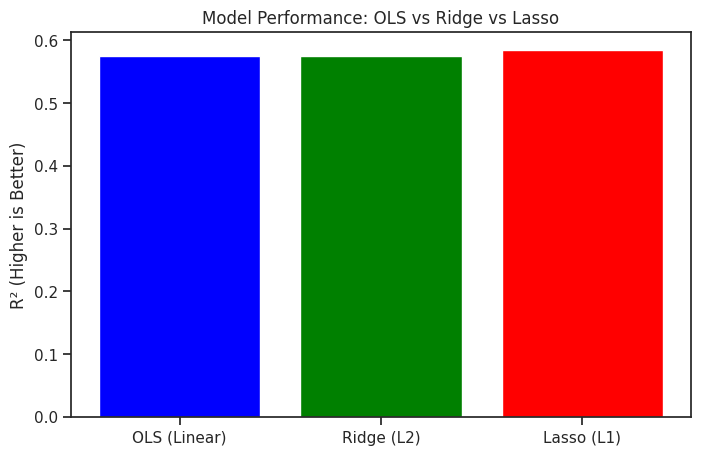


📌 Coefficient Comparison (OLS vs Ridge vs Lasso):

               OLS   Ridge   Lasso
Feature                           
MedInc      0.4487  0.4485  0.4089
HouseAge    0.0097  0.0097  0.0103
AveRooms   -0.1233 -0.1230 -0.0474
AveBedrms   0.7831  0.7814  0.3633
Population -0.0000 -0.0000 -0.0000
AveOccup   -0.0035 -0.0035 -0.0034
Latitude   -0.4198 -0.4198 -0.4071
Longitude  -0.4337 -0.4337 -0.4149


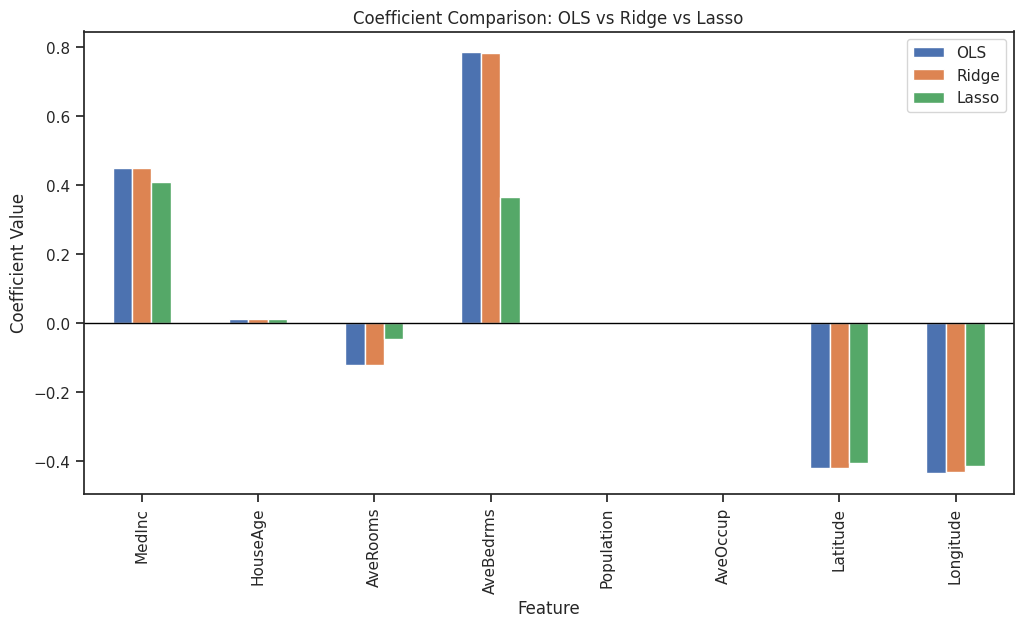

In [ ]:
# ------------------------------------------------------------
# Step 1: Import required libraries
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# ------------------------------------------------------------
# Step 2: Load dataset (California Housing dataset)
# ------------------------------------------------------------
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------------------------------------
# Step 3: Fit Base Linear Regression (OLS)
# ------------------------------------------------------------
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols = r2_score(y_test, y_pred_ols)

# ------------------------------------------------------------
# Step 4: Ridge Regression (L2 Regularization)
# ------------------------------------------------------------
ridge = Ridge(alpha=1.0)   # alpha controls strength of penalty
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# ------------------------------------------------------------
# Step 5: Lasso Regression (L1 Regularization)
# ------------------------------------------------------------
lasso = Lasso(alpha=0.01)  # small alpha, otherwise everything → 0
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

# ------------------------------------------------------------
# Step 6: Compare Performances
# ------------------------------------------------------------
results = pd.DataFrame({
    "Model": ["OLS (Linear)", "Ridge (L2)", "Lasso (L1)"],
    "RMSE": [rmse_ols, rmse_ridge, rmse_lasso],
    "R²": [r2_ols, r2_ridge, r2_lasso]
})

print("📊 Model Performance Comparison:\n")
print(results)

# ------------------------------------------------------------
# Step 7: Visualization - Performance
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R²"], color=['blue','green','red'])
plt.ylabel("R² (Higher is Better)")
plt.title("Model Performance: OLS vs Ridge vs Lasso")
plt.show()

# ------------------------------------------------------------
# Step 8: Coefficient Comparison (Table + Plot)
# ------------------------------------------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Set feature names as index for cleaner view
coefficients.set_index("Feature", inplace=True)

# Print nicely
print("\n📌 Coefficient Comparison (OLS vs Ridge vs Lasso):\n")
print(coefficients.round(4).to_string())

# ------------------------------------------------------------
# Step 9: Plot Coefficients
# ------------------------------------------------------------
coefficients.plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison: OLS vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.axhline(0, color="black", linewidth=1)
plt.show()


**What this means:**

OLS (Linear Regression): Baseline model. RMSE = 0.746, R² = 0.576 → It explains about 57% of variance.

Ridge (L2 Regularization): RMSE and R² are almost the same as OLS. Ridge didn’t change much here because the dataset doesn’t have severe multicollinearity or extremely large coefficients. Ridge mainly helps when features are highly correlated.

Lasso (L1 Regularization): RMSE improved slightly (0.738 vs 0.746) and R² also improved (0.585 vs 0.576). Lasso helped by removing less important features, making the model simpler and slightly more accurate.

**👉 Takeaway :**

Ridge usually helps when we have multicollinearity.

Lasso is useful for feature selection — it can set unimportant coefficients exactly to zero.

Here, Lasso gave us a small boost in performance.

**What this means:**

MedInc (Median Income): Strong positive effect across all models. Lasso reduced it slightly but kept it important → still the most predictive feature.

HouseAge: Very small effect in all models. Lasso didn’t shrink it to zero, but the contribution is minimal.

AveRooms (Average Rooms): OLS & Ridge = negative, Lasso = much smaller negative. Lasso is saying → “this feature is less important, I’ll shrink it down.”

AveBedrms (Average Bedrooms): Big positive in OLS/Ridge, but Lasso cut it almost in half. → Suggests this feature has some redundancy with others (maybe correlated with AveRooms).

Population: Already near zero, and Lasso kept it at zero → not important for prediction.

AveOccup (Average Occupancy): Small negative, almost unchanged.

Latitude & Longitude: Both strongly negative (location effect). Lasso shrinks them slightly but keeps them important.

**👉 Takeaway:**

Lasso: aggressively shrinks some coefficients (AveRooms, AveBedrms, Population) → acts like feature selection.

Ridge: only slightly reduces coefficients, but keeps all features in the model.

OLS: uses all features without any penalty.

**Final Intuition:**

OLS (Linear): Fits data directly, but can overfit if too many correlated features.

Ridge (L2): Shrinks coefficients smoothly → useful when features are correlated. Keeps all features but smaller values.

Lasso (L1): Shrinks aggressively → sets some coefficients to zero → performs automatic feature selection.

Here:

The dataset doesn’t have extreme multicollinearity, so Ridge didn’t help much.

Lasso worked slightly better by dropping weak features (Population, shrinking AveRooms & AveBedrms).

OLS = Standard baseline

Ridge = Smoother version (good for correlated features)

Lasso = Simpler version (good for feature selection)